# 5.2.3 🏀 TrackID3x3 による選手追跡・フィールド登録・選手識別
TrackID3x3を実装してMinimapを作成しよう！

## 参考
*   論文：https://arxiv.org/abs/2503.18282v1
*   コード：https://github.com/open-starlab/TrackID3x3


## クレジット
*   Authors: Kazuhiro Yamada & Keisuke Fujii
*   Affiliation: Nagoya University
*   Last updated: 2025-12-07
*   License: CC BY 4.0

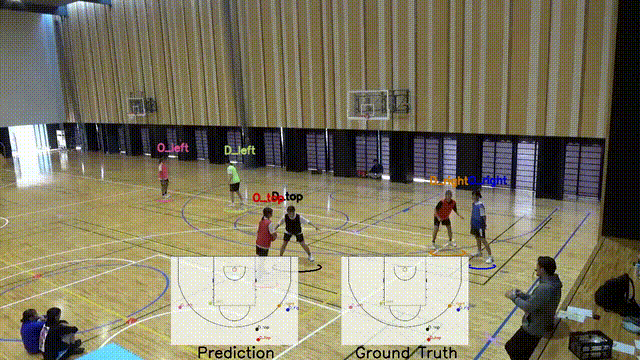

**このノートブックの実行手順:**

1.  環境準備
2.  データダウンロード
3.  モデルロード & トラッキング
4.  MOT フォーマット txt を作成・描画付き動画を作成
5.  ホモグラフィ用キーポイントの読み込み
6.  MOT txt 読み込み・Track-ID Baselineの処理
7.  属性割り当て実行・予測結果の保存
8. 評価指標算出のための関数定義
9. 評価指標算出
10. ミニマップ用ヘルパー関数定義
11. 動画作成（GT と予測それぞれ）
12. ミニマップ動画合成
13. （おまけ）移動距離の算出

# 1. 環境準備

In [1]:
# ===============================
#  1. 環境準備
# ===============================
!pip install ultralytics --quiet
!pip install ndjson --quiet

import os, glob, re, random, cv2, ndjson, math
from re import VERBOSE
import numpy as np
import pandas as pd
import colorsys
from ultralytics import YOLO
from google.colab import files
from IPython.display import HTML
from base64 import b64encode
from collections import defaultdict
from scipy.spatial.distance import cdist


# GPU が使えるか確認
import torch
assert torch.cuda.is_available(), "GPU ランタイムを有効にしてください"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# 2. 必要なファイルを以下からダウンロードします。

*   basket_S1T3_pre.mp4
*   Indoor_court_keypoints.ndjson
*   basket_S1T3_pre_GT.txt
*   Indoor_court.jpg
*   basket_1st_frame.jpg

https://drive.google.com/drive/folders/1c5HLFx0JR_ujXg4Ft7lkV5I-AHBmpTJS?usp=sharing

In [2]:
# ===============================
#  2. ファイルをダウンロード
# ===============================
!pip install gdown --quiet

print("Downloading files from Google Drive...")
!gdown https://drive.google.com/uc?id=1lkJ_smiH1Bs-wFVgClC57I9yohXXle92 # basket_S1T3_pre.mp4
!gdown https://drive.google.com/uc?id=1UkahwaVgICiQMG8HAnHFkrCcWUMEL1t9 # Indoor_court_keypoints.ndjson
!gdown https://drive.google.com/uc?id=1yurDB4keKywSa4USNJdKZo2GNaj3AfJF # basket_S1T3_pre_GT.txt
!gdown https://drive.google.com/uc?id=1nn9DozJ-KVMUlA0H658almf4jeK2lQAH # Indoor_court.jpg
!gdown https://drive.google.com/uc?id=1_ofVbXSq2HBVq2o10VVko7SBJAnoJJsa # basket_1st_frame.jpg

video_path = "basket_S1T3_pre.mp4"
print("Input video:", video_path)

Downloading...
From: https://drive.google.com/uc?id=1lkJ_smiH1Bs-wFVgClC57I9yohXXle92
To: /content/basket_S1T3_pre.mp4
100% 1.94M/1.94M [00:00<00:00, 83.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1UkahwaVgICiQMG8HAnHFkrCcWUMEL1t9
To: /content/Indoor_court_keypoints.ndjson
100% 16.2k/16.2k [00:00<00:00, 19.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1yurDB4keKywSa4USNJdKZo2GNaj3AfJF
To: /content/basket_S1T3_pre_GT.txt
100% 63.1k/63.1k [00:00<00:00, 84.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1nn9DozJ-KVMUlA0H658almf4jeK2lQAH
To: /content/Indoor_court.jpg
100% 24.1k/24.1k [00:00<00:00, 51.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_ofVbXSq2HBVq2o10VVko7SBJAnoJJsa
To: /content/basket_1st_frame.jpg
100% 211k/211k [00:00<00:00, 84.1MB/s]
Input video: basket_S1T3_pre.mp4


# 3. トラッキング

このノートブックでは理解のため、モデルは簡潔なもの（ByteTrackなど）を用います。


（詳しい方法は、論文を参照：https://arxiv.org/abs/2503.18282v1 ）

In [3]:
# ===============================
#  3. モデルロード & トラッキング
# ===============================
# モデルは yolov11x.ptを使用
# 他のモデルを使用する場合は、以下の行の "yolo11x.pt" を変更します
# 例: YOLO("yolov8n.pt") # Nanoモデル
# 例: YOLO("yolov8s.pt") # Smallモデル
# 例: YOLO("yolov8m.pt") # Mediumモデル
# 例: YOLO("yolov8l.pt") # Largeモデル
# 例: YOLO("yolov8x.pt") # Extra-Largeモデル
model = YOLO("yolo11x.pt")

# tracker='bytetrack.yaml' で ByteTrack を選択
# 他のトラッカーを使用する場合は、以下の行の "bytetrack.yaml" を変更します
# 例: tracker='botsort.yaml' # BoT-SORT
# 例: tracker='deepocsort.yaml' # DeepOCSORT
# save=True で追跡後のアノテーション動画を保存
# save_txt=True で "runs/track/exp/labels/*.txt" にトラッキング結果を各フレームごとに YOLO TXT 形式で出力
# save_conf=True でスコアも併記
# device="0" で Colab の GPU を指定

results = model.track(
    source=video_path,
    tracker="bytetrack.yaml",
    device="0",        # GPU 使用
    classes=[0],       # person クラスのみ（COCO ID 0）
    save=True,         # アノテーション付き動画保存
    save_txt=True,     # .txt 出力
    save_conf=True,
    verbose=False
)

out_dir = results[0].save_dir
print("▶ 出力フォルダ:", out_dir)

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 2 packages in 161ms
Prepared 1 package in 49ms
Installed 1 package in 3ms
 + lap==0.5.12

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /content/runs/detect/track
216 labels saved to /content/runs/detect/track/labels
▶ 出力

# 4. データフォーマットの変換

In [4]:
# ==============================================================
#  4. MOT フォーマット txt を作成・描画付き動画を作成
#  追跡結果のMOT形式ファイルを処理し、
#  ID ごとに色分けされたアノテーション付き動画を生成します。
# ==============================================================


# -------------------------------
#  bbox描画ヘルパー関数
# -------------------------------
def get_frame_id_from_filename(path):
    """
    ファイル名末尾の数字列をフレーム番号として返す。
    例: '000123.txt' → 123, 'basket_S1T3_pre_1.txt' → 1
    """
    base = os.path.splitext(os.path.basename(path))[0]
    m = re.search(r'(\d+)$', base)
    if not m:
        raise ValueError(f"No frame number found in filename '{base}'")
    return int(m.group(1))

def parse_line(parts):
    """
    parts: ラベルファイルの split() 後リスト
    戻り値: (tid, conf, xc, yc, w_rel, h_rel)
    """
    # クラスID (未使用なら読み飛ばし)
    cls = int(parts[0])
    # 中心座標・幅高さ (相対値)
    xc, yc, w_rel, h_rel = map(float, parts[1:5])

    # track_id と confidence の順序を自動判別
    if len(parts) >= 7:
        a, b = parts[5], parts[6]
        try:
            # a が整数なら a=track_id, b=confidence
            tid = int(a)
            conf = float(b)
        except ValueError:
            # それ以外は a=confidence, b=track_id
            conf = float(a)
            tid = int(b)
    elif len(parts) == 6:
        # track_id のみ出力されている場合
        tid = int(parts[5])
        conf = 1.0
    else:
        raise ValueError(f"Cannot parse parts: {parts}")

    return tid, conf, xc, yc, w_rel, h_rel

def get_color(track_id):
    """
    track_id から一意かつ十分に分離された色を決定論的に生成
    """
    hval = abs(hash(track_id))
    r = 50 + (hval % 206)
    g = 50 + ((hval // 206) % 206)
    b = 50 + ((hval // (206*206)) % 206)
    return (r, g, b)

# -------------------------------
#  MOT フォーマット txt を作成
# -------------------------------
mot_txt_path = os.path.join(out_dir, "mot_results.txt")
label_dir   = os.path.join(out_dir, "labels")
label_files = sorted(
    glob.glob(os.path.join(label_dir, "*.txt")),
    key=get_frame_id_from_filename
)

# 動画情報を取得
cap = cv2.VideoCapture(video_path)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps     = cap.get(cv2.CAP_PROP_FPS)
cap.release()

with open(mot_txt_path, "w") as mot_f:
    for lf in label_files:
        frame_id = get_frame_id_from_filename(lf)
        with open(lf, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 6:
                    continue
                tid, conf, xc, yc, w_rel, h_rel = parse_line(parts)

                # 相対→絶対座標
                w_pix = w_rel * width
                h_pix = h_rel * height
                x_pix = xc * width  - w_pix / 2
                y_pix = yc * height - h_pix / 2

                # MOTChallenge フォーマット: frame, id, left, top, width, height, score, -1,-1,-1
                mot_f.write(
                    f"{frame_id},{tid},{x_pix:.2f},{y_pix:.2f},"
                    f"{w_pix:.2f},{h_pix:.2f},{conf:.2f},-1,-1,-1\n"
                )
print("▶ MOT フォーマット出力:", mot_txt_path)

# -------------------------------
#  MOT結果をメモリにロード
# -------------------------------
mot_data = defaultdict(list)
with open(mot_txt_path, "r") as mot_f:
    for line in mot_f:
        fid, tid, x, y, w, h, conf, *_ = line.strip().split(",")
        mot_data[int(fid)].append({
            "id": int(tid),
            "bbox": (float(x), float(y), float(w), float(h)),
            "conf": float(conf)
        })

# -------------------------------
#  カラー付きで動画を描画
# -------------------------------
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out_mp4 = os.path.join(out_dir, "tracked_visualization.mp4")

# 全ユニーク track_id を取得
unique_ids = sorted({
    det["id"]
    for dets in mot_data.values()
    for det in dets
})

# ID ごとの色相を等間隔に分割して RGB に変換
id2color = {}
n = len(unique_ids)
for idx, tid in enumerate(unique_ids):
    # hue: 0.0〜1.0 の範囲を均等に
    h = idx / n
    # 彩度=1.0, 明度=1.0
    r, g, b = colorsys.hsv_to_rgb(h, 1.0, 1.0)
    # OpenCV は BGR の 0–255
    id2color[tid] = (int(b*255), int(g*255), int(r*255))

# 2) 動画描画部で get_color() の代わりに id2color を使う
cap    = cv2.VideoCapture(video_path)
writer = cv2.VideoWriter(out_mp4, fourcc, fps, (width, height))

while True:
    ret, frame = cap.read()
    if not ret: break
    frame_id = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
    for det in mot_data.get(frame_id, []):
        tid = det["id"]
        x, y, w, h = det["bbox"]
        color = id2color[tid]   # ← ここを変更
        cv2.rectangle(frame, (int(x), int(y)), (int(x+w), int(y+h)), color, 2)
        cv2.putText(frame, str(tid),
                    (int(x), int(y)-6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8,
                    (0,0,255), 2)
    writer.write(frame)
cap.release()
writer.release()


cap.release()
writer.release()
print("▶ 描画付き動画出力:", out_mp4)

▶ MOT フォーマット出力: /content/runs/detect/track/mot_results.txt
▶ 描画付き動画出力: /content/runs/detect/track/tracked_visualization.mp4


# 5.  ホモグラフィ用キーポイントの読み込み:

　　アップロードされた NDJSON ファイルからキーポイントを読み込み、

　　画像座標系からコート座標系へのホモグラフィ変換行列 (H) を計算します。



In [5]:
# ==============================
#  5. ホモグラフィ用キーポイントの読み込み
# ==============================
with open("/content/Indoor_court_keypoints.ndjson", "r") as f:
    data = ndjson.load(f)

annotations = data[0]["projects"]["clqqo8sg92kjv07yx56yad247"]["labels"][0]["annotations"]["objects"]

# キーポイントマッピング
keypoint_mapping = {
    "key_1_tokoha":   [0,    0],
    "key_6_tokoha":   [0, 1505],
    "key_9_tokoha":   [950,  0],
    "key_12_tokoha": [950, 1505]
}

pts_img   = []
pts_court = []
for obj in annotations:
    name = obj["value"]
    if name in keypoint_mapping:
        x, y = obj["point"]["x"], obj["point"]["y"]
        pts_img.append([x, y])
        pts_court.append(keypoint_mapping[name])

pts_img   = np.array(pts_img,   dtype=np.float32)
pts_court = np.array(pts_court, dtype=np.float32)

print("▶ Keypoint in image:\n",pts_img)

# Homography 計算
H, _ = cv2.findHomography(pts_img, pts_court)
print("▶ Homography:\n", H)

# 変換関数
def homographic_transformation(x, y, H):
    p = np.array([x, y, 1.0]).reshape(3,1)
    tp = H.dot(p)
    tp /= tp[2,0]
    return float(tp[0,0]), float(tp[1,0])

min_x, min_y = keypoint_mapping["key_1_tokoha"]
max_x, max_y = keypoint_mapping["key_12_tokoha"]
max_x += 100  # マージン

▶ Keypoint in image:
 [[     121.54      430.87]
 [     983.04      678.37]
 [     509.65      346.44]
 [     1182.1      423.03]]
▶ Homography:
 [[     1.0027     -8.8039        2539]
 [    -1.9394     -8.9157      4077.2]
 [-0.00015815  -0.0050429           1]]


変換が正しく行われているかチェック

In [6]:
first_frame = "/content/basket_1st_frame.jpg"

img = cv2.imread(first_frame)

court_width_pixels = 1500 # set manually
court_height_pixels = 1500 # set manually

# Apply homography transformation
warped_court_image = cv2.warpPerspective(img, H, (court_width_pixels, court_height_pixels))

from google.colab.patches import cv2_imshow
cv2_imshow(warped_court_image)

output_image_path = "transformed_court_image.jpg"
cv2.imwrite(output_image_path, warped_court_image)

print(f"Rectified court image saved to {output_image_path}")

Output hidden; open in https://colab.research.google.com to view.

# 6.  MOT txt 読み込み・Track-ID Baselineの処理:

　　まず追跡結果のMOTファイルを読み込み、ホモグラフィ変換を適用してコート座標系での位置を算出します。

　　次にトラックレベルおよび検出レベルのフィルタリングを行い、不要な検出を除外します。

　　さらにIDスイッチの検出と統合を行い、線形補間と末端外挿で欠損データを補完します。

　　最後にフィルタリングされた bbox 情報とコート座標情報を新しいテキストファイルとして出力します。

　　（論文：https://arxiv.org/abs/2503.18282v2 のIndoorの処理を簡単に実装しています）

In [7]:
# ==========================================
#  6. MOT txt 読み込み・Track-ID Baselineの処理
# ==========================================
# mot_txt_path をそのまま読み込む
cols = [
    "frame_id", "id",
    "x", "y", "width", "height",
    "conf",      # confidence
    "class",     # dummy (元 -1)
    "visibility",# dummy (元 -1)
    "empty"      # dummy (元 -1)
]
df = pd.read_csv(mot_txt_path, names=cols, sep=",")

# 底辺中心を計算 (バウンディングボックスの下辺の中央)
df["bot_cx"] = df["x"] + df["width"]/2
df["bot_cy"] = df["y"] + df["height"]

# ホモグラフィ変換を使って、画像座標系での底辺中心をコート座標系に変換
df[["court_x","court_y"]] = df.apply(
    lambda r: homographic_transformation(r["bot_cx"], r["bot_cy"], H),
    axis=1, result_type="expand"
)

# トラックレベルフィルタ: トラック全体を評価して、不要なトラックを除外
valid_ids = []
for tid, grp in df.groupby("id"):
    total = grp["frame_id"].nunique() # そのIDが出現する総フレーム数
    inside = grp[
        (grp["court_x"]>=min_x)&(grp["court_x"]<=max_x)& # コートの最小x～最大xの範囲内
        (grp["court_y"]>=min_y)&(grp["court_y"]<=max_y) # コートの最小y～最大yの範囲内
    ]
    # max_run 計算: コート内に連続して存在した最長フレーム数を計算
    frames = sorted(inside["frame_id"].unique())
    max_run = 0; cur = 0; prev = None
    for f in frames:
        cur = cur+1 if prev is not None and f==prev+1 else 1
        max_run = max(max_run, cur); prev = f

    # コートの外側（左右）に存在したフレーム数をカウント
    c1 = (grp["court_x"] < min_x).sum() # コート左側
    c2 = (grp["court_x"] > max_x).sum() # コート右側

    # フィルタリング条件:
    # 1. コート内に連続して10フレーム以上存在したことがある (max_run >= 10)
    # 2. コートの左側に存在するフレーム数が総フレーム数の半分以下 (c1 <= total/2)
    # 3. コートの右側に存在するフレーム数が総フレーム数の半分以下 (c2 <= total/2)
    # これらの条件を満たすトラックIDのみを有効とする
    if max_run>=10 and c1<=total/2 and c2<=total/2:
        valid_ids.append(tid)

# 有効と判断されたトラックIDのみをデータフレームに残す
df = df[df["id"].isin(valid_ids)].copy()

# 検出レベルフィルタ：コートから3m（300cm）以上離れている検出を除外
buffer_cm = 300  # 3m = 300cm
df = df[
        (df["court_x"] >= min_x - buffer_cm) &
        (df["court_x"] <= max_x + buffer_cm) &
        (df["court_y"] >= min_y - buffer_cm) &
        (df["court_y"] <= max_y + buffer_cm)
        ].copy() # フィルタリング後にコピーを作成

# 動画全体のフレーム範囲を算出
global_min = df["frame_id"].min()
global_max = df["frame_id"].max()

# フレーム番号 1 〜 global_max が存在するなら総フレーム数は global_max
total_video_frames = global_max

# ID Switch 検出・統合
first_frame_global = global_min
orig_ids = df[df["frame_id"] == first_frame_global]["id"].unique()
new_ids  = sorted([i for i in df["id"].unique() if i not in orig_ids])

total_frames = df["frame_id"].max()

for new in new_ids:
    frames_new = set(df[df["id"] == new]["frame_id"].unique())
    first_n    = min(frames_new)
    if first_n <= first_frame_global:
        df = df[df["id"] != new]
        continue

    cands = []
    for orig in orig_ids:
        # ── コート内フレームだけを取る ──
        inside_orig = set(
            df[
                (df["id"] == orig) &
                (df["court_x"].between(min_x, max_x)) &
                (df["court_y"].between(min_y, max_y))
            ]["frame_id"]
        )
        inside_new  = set(
            df[
                (df["id"] == new) &
                (df["court_x"].between(min_x, max_x)) &
                (df["court_y"].between(min_y, max_y))
            ]["frame_id"]
        )

        # overlap をコート内同時存在フレーム数に
        overlap = len(inside_orig & inside_new)
        if overlap >= 10: # 同時存在フレームが10以上なら、IDスイッチではないとみなしスキップ
            continue

        union_frames = inside_orig | inside_new
        missing = total_frames - len(union_frames)
        cost    = overlap + missing # コストは重複フレーム数 + 欠損フレーム数 (小さい方が良い)
        cands.append((orig, cost, overlap, missing))

    if not cands:
        # マージ候補がない場合はそのまま
        continue

    # コストが最小の候補を選択
    best_orig, cost, overlap, missing = min(cands, key=lambda x: x[1])

    # 重複期間は orig を残し new を削除
    # → まず new をまとめて best_orig にリネーム
    df.loc[df["id"] == new, "id"] = best_orig
    # → その上で重複行を削除（frame_id と id が同じ行を削除。keep="first" で元の id (best_orig) の行が優先される）
    df = df.drop_duplicates(subset=["frame_id","id"], keep="first")

    print(f"Merge ID Switch: new={new} → orig={best_orig} "
          f"(cost={cost}, overlap={overlap}, missing={missing})")
#--- ここまで ID Switch ---

# 線形補間＋末端外挿
filled = []

# 補間・外挿の対象列を bbox と court_coords の両方に
bbox_cols    = ["x", "y", "width", "height"]
court_cols   = ["court_x", "court_y"]
numeric_cols = bbox_cols + court_cols

for tid, grp in df.groupby("id"):
    grp = grp.set_index("frame_id").sort_index()
    # 全フレームでリインデックス (欠損フレームをNaNで埋める)
    full_idx = range(global_min, global_max + 1)
    grp = grp.reindex(full_idx)

    # ID, class, conf, visibility, empty は前方バックフィル (NaNを直前の有効値で埋める)
    grp["id"] = tid
    for col in ["class", "conf", "visibility", "empty"]:
        grp[col] = grp[col].ffill().bfill()

    # (a) 中心部：前後の有効データで線形補間
    grp[numeric_cols] = grp[numeric_cols].interpolate(
        method="linear", limit_direction="both" # 前後両方向に補間
    )

    # (b) 末端外挿：最後の有効データ以降を直前２フレーム差分で延長
    last_valid = grp[numeric_cols].last_valid_index()
    if last_valid is not None and last_valid < global_max:
        prev2 = last_valid - 1
        if prev2 in grp.index:
            p1 = grp.loc[prev2, numeric_cols]
            p2 = grp.loc[last_valid, numeric_cols]
            delta = p2 - p1 # 直近2フレームの差分
            for f in range(last_valid + 1, global_max + 1):
                # 最後の有効データに差分を加えて延長
                grp.loc[f, numeric_cols] = p2 + delta * (f - last_valid)

    # (c) 必要なら先頭外挿も同様に (今回は省略)
    # …（省略）…

    grp = grp.reset_index().rename(columns={"index": "frame_id"})
    filled.append(grp)

# 補間・外挿されたデータを結合
df = pd.concat(filled, ignore_index=True)

# 各トラックIDがコート内に存在したフレーム数を計算 (フィルタリングの参考用、現在は未使用)
in_court_counts = df.groupby("id").apply(
    lambda g: ((g["court_x"].between(min_x, max_x)) &
                (g["court_y"].between(min_y, min_y))).sum()
)
# map して新しい列に (現在は未使用だが計算は残す)
df["in_court_count"] = df["id"].map(in_court_counts)

# 検出数制限：1フレームごとに最大6つまで（競技に応じた制限）
# in_court_count が少ないものや ID が大きいものから削除して、最大6検出に絞る
def limit(sub):
    # 6以下ならそのまま返す
    if len(sub) <= 6:
        return sub
    drop_n = len(sub) - 6 # 削除する検出数
    # in_court_count が少ないもの→優先削除、
    # 同率なら id が大きいものから削除
    to_drop = (sub
        .sort_values(["in_court_count","id"], ascending=[True, False])
        .iloc[:drop_n] # 削除する行のインデックスを取得
        .index
    )
    return sub.drop(to_drop) # 該当する行を削除

# frame_id ごとに制限を適用
df = df.groupby("frame_id", group_keys=False).apply(limit)

# 警告出力：1フレームの検出数が6個未満の場合に警告を表示
for frame_id, group in df.groupby("frame_id"):
    cnt = len(group)
    if cnt < 6:
        print(f"[Warning]: frame {frame_id} has only {cnt} detections.")

# ここで df 自体がフィルタ済みなので、bbox 側にもそのまま反映される
# 最終的な出力用のデータフレームを作成
df_bbox  = df[["frame_id","id","x","y","width","height","conf","class","visibility","empty"]]
df_court = df[["frame_id","id","court_x","court_y"]]

# ==============================
#  結果の出力
# ==============================

# フィルタ後の MOT bbox 形式で出力
out_bbox  = os.path.join(out_dir, "filtered_mot.txt")
df_bbox[["frame_id","id","x","y","width","height","conf"]].to_csv(
    out_bbox, index=False, header=False, sep=",")

# コート座標のみを TXT 形式で出力
out_court = os.path.join(out_dir, "transformed_court.txt")
df_court[["frame_id","id","court_x","court_y"]].to_csv(out_court, index=False, header=False)


print("▶ 出力完了:")
print("   - Court txt:", out_court)
print("   - Filtered MOT txt:", out_bbox)

Merge ID Switch: new=36 → orig=7 (cost=24, overlap=0, missing=24)
Merge ID Switch: new=61 → orig=2 (cost=80, overlap=0, missing=80)
▶ 出力完了:
   - Court txt: /content/runs/detect/track/transformed_court.txt
   - Filtered MOT txt: /content/runs/detect/track/filtered_mot.txt


/tmp/ipython-input-2272068123.py:176: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  in_court_counts = df.groupby("id").apply(
/tmp/ipython-input-2272068123.py:200: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("frame_id", group_keys=False).apply(limit)


# 7. 属性割り当て実行・予測結果の保存:

まず初期フレームの検出に基づいて D/O (守備/攻撃) の役割と位置 (right/top/left) を割り当て、全フレームに適用するための関数 `assign_attributes` を定義します。
次にフィルタリング済みのコート座標ファイル (`transformed_court.txt`) を読み込み、`assign_attributes` 関数を使用して属性を割り当てます。
最終的に、属性が割り当てられた最終的な予測結果を新しいテキストファイル (`transformed_court_with_attributes.txt`) として保存します。

In [8]:
# ==============================
#  属性割り当て関数
# ==============================

from scipy.spatial.distance import cdist

def assign_attributes(df):
    """
    初期フレーム（frame==1）の検出点をもとにD/Oペアと位置を決定し、
    すべてのフレームにその役割を適用します。
    検出数が2以上の場合は最低1ペアを、最大3ペアまで作成。
    余った点には既存の役割を循環割り当てし、nan_nanは発生しません。
    検出数が1以下の場合は全てnan_nanとなります。
    """
    # 初期フレーム抽出
    initial = df[df['frame'] == 1].copy()
    n_points = len(initial)
    # ペア数の決定: 点数//2 の最大3、最小1
    if n_points < 2:
        df['assigned_role'] = 'nan_nan'
        return df
    n_pairs = min(3, n_points // 2)
    n_pairs = max(1, n_pairs)

    # 初期フレーム上で距離行列を計算
    coords = initial[['x', 'y']].values
    dist_matrix = cdist(coords, coords)
    np.fill_diagonal(dist_matrix, np.inf)

    # 最も近いペアをn_pairs組取得
    pairs = []
    tmp = dist_matrix.copy()
    for _ in range(n_pairs):
        idx = np.argmin(tmp)
        i, j = divmod(idx, tmp.shape[1])
        pairs.append((initial.iloc[i], initial.iloc[j]))
        tmp[i, :] = np.inf
        tmp[:, i] = np.inf
        tmp[j, :] = np.inf
        tmp[:, j] = np.inf

    # ゴール位置(0,752.5)を基準にD/Oを決定
    reference = np.array([0, 752.5])
    pair_roles = []
    for p1, p2 in pairs:
        d1 = np.linalg.norm(p1[['x', 'y']].values - reference)
        d2 = np.linalg.norm(p2[['x', 'y']].values - reference)
        if d1 < d2:
            pair_roles.append((p1, 'D', p2, 'O'))
        else:
            pair_roles.append((p2, 'D', p1, 'O'))

    # yの中点でソートし、right/top/leftを割り当て
    positions = ['right', 'top', 'left'][:n_pairs]
    mid_list = sorted(
        [((p1['y'] + p2['y']) / 2, p1, rD, p2, rO)
         for (p1, rD, p2, rO) in pair_roles],
        key=lambda x: x[0], reverse=True
    )

    # ID→役割マッピングの作成
    role_map = {}
    for idx, (_, pD, rD, pO, rO) in enumerate(mid_list):
        pos = positions[idx]
        role_map[pD['ID']] = f"{rD}_{pos}"
        role_map[pO['ID']] = f"{rO}_{pos}"

    # 全フレームにマッピングを適用（nan_nanは発生しない）
    df['assigned_role'] = df['ID'].map(role_map)
    return df

# ====================================
#  属性割り当て実行・最終的な予測結果の保存
# ====================================

input_txt  = os.path.join(out_dir, "transformed_court.txt")  # または .csv の拡張子に合わせてください
output_txt = os.path.join(out_dir, "transformed_court_with_attributes.txt")

# 読み込み
df = pd.read_csv(
    input_txt,
    header=None,
    names=["frame", "ID", "x", "y"],
    sep=",",
    dtype={"frame": int, "ID": int, "x": float, "y": float}
)

# 役割割当
df2 = assign_attributes(df)

# TXT 形式で書き出し（ヘッダーなし）
df2.to_csv(
    output_txt,
    sep=",",
    header=False,
    index=False
)

print("▶ 完了:", output_txt)


▶ 完了: /content/runs/detect/track/transformed_court_with_attributes.txt


# 8. 評価指標算出のための関数定義:

論文で定義されている TI-HOTA 評価指標を計算するための関数群 (loc_sim, id_sim, sim_ti_hota, compute_ti_hota_alpha, compute_ti_hota, load_frames, load_video) を定義します。

評価関数は、論文中の以下の式から定義します。

（SoccerNetの[Game State Reconstruction](https://github.com/SoccerNet/sn-gamestate)を参考に、フィールド認識を省いて構成しました）

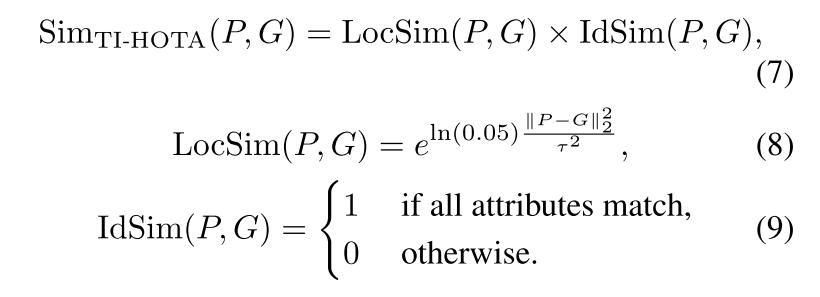

In [9]:
# =========================
#  8. 評価指標算出のための関数定義
# =========================


import numpy as np
import math
from scipy.optimize import linear_sum_assignment

# Calculation of location similarity LocSim
def loc_sim(P_pos, G_pos, tau):
    """
    Function to compute location similarity LocSim

    \operatorname{LocSim}(P, G) = \exp\!\left( \ln(0.05) \cdot \frac{\|P - G\|_2^2}{\tau^2} \right)

    :param P_pos: Predicted position (coordinates in list or numpy array)
    :param G_pos: Ground Truth Location
    :param tau: normalized parameter
     # tauは距離のスケールを調整し、どれだけ離れると類似度が低下するかを決定する。単位はcm。
    :return: LocSim Value
    """
    P_pos = np.array(P_pos)
    G_pos = np.array(G_pos)
    distance_sq = np.sum((P_pos - G_pos)**2)
    sim = math.exp(math.log(0.05) * (distance_sq / (tau**2)))
    return sim

# Calculation of attribute similarity IdSim
def id_sim(P_attr, G_attr):
    """
    Function to calculate attribute similarity IdSim

    \operatorname{IdSim}(P, G) =
    \begin{cases}
    1, & \text{if } P_{\text{attr}} = G_{\text{attr}}, \\
    0, & \text{otherwise.}
    \end{cases}

    :param P_attr: Attributes of prediction (specify each attribute in a dictionary, etc.)
    :param G_attr: Ground Truth Attributes
    :return: 1 if all attributes match, 0 otherwise
    """

    return 1 if P_attr == G_attr else 0

# Overall similarity of each pair
def sim_ti_hota(P, G, tau):
    """
    Function to calculate the overall similarity of TI-HOTA

    \operatorname{Sim}_{\mathrm{TI\text{-}HOTA}}(P, G) = \operatorname{LocSim}(P, G) \times \operatorname{IdSim}(P, G)

    :param P: Prediction Information {'position': [x, y, ...], 'attributes': {...}}
    :param G: Ground Truth Information {'position': [x, y, ...], 'attributes': {...}}
    :param tau: normalized parameter for loc_sim calculation
    :return: overall similarity Sim_{TI-HOTA}
    """

    return loc_sim(P['position'], G['position'], tau) * id_sim(P['attributes'], G['attributes'])

def compute_ti_hota_alpha(frames, tau, alpha):
    total_tp = total_fp = total_fn = 0
    assoc_counts = {}
    fpa_counts = {}

    for frame in frames:
        gt_objs = frame.get('ground_truths', [])
        pred_objs = frame.get('predictions', [])
        n_gt, n_pred = len(gt_objs), len(pred_objs)

        # Build similarity and cost matrices
        combined = np.zeros((n_gt, n_pred))
        cost = np.zeros((n_gt, n_pred))
        for i, gt in enumerate(gt_objs):
            for j, pred in enumerate(pred_objs):
                loc = loc_sim(pred['position'], gt['position'], tau)
                combined[i, j] = loc * id_sim(pred['attributes'], gt['attributes'])
                cost[i, j] = 1 - combined[i, j]

        # Exclude below-threshold pairs
        cost[combined < alpha] = 1e6
        row_ind, col_ind = linear_sum_assignment(cost)

        # Determine current valid matches
        curr_gt_match = {}
        for i, j in zip(row_ind, col_ind):
            if combined[i, j] >= alpha:
                curr_gt_match[i] = j

        # Update detection counts
        tp = len(curr_gt_match)
        fp = n_pred - tp
        fn = n_gt   - tp
        total_tp += tp
        total_fp += fp
        total_fn += fn

        # Association counts (for AssA calculation)
        matched_gt = set(curr_gt_match.keys())
        for i, gt in enumerate(gt_objs):
            gid = gt['attributes']
            assoc_counts.setdefault(gid, {'TPA': 0, 'FNA': 0})
            if i not in matched_gt:
                assoc_counts[gid]['FNA'] += 1
        for i, j in curr_gt_match.items():
            gid = gt_objs[i]['attributes']
            assoc_counts[gid]['TPA'] += 1
        for j, pred in enumerate(pred_objs):
            if j not in curr_gt_match.values():
                pid = pred['attributes']
                fpa_counts[pid] = fpa_counts.get(pid, 0) + 1

    # Compute average DetA and AssA
    total_det = total_tp + total_fp + total_fn
    det_acc = total_tp / total_det if total_det > 0 else 0
    sum_A = n_tracks = 0
    for gid, cnt in assoc_counts.items():
        denom = cnt['TPA'] + cnt['FNA'] + fpa_counts.get(gid, 0)
        if denom > 0:
            sum_A += cnt['TPA'] / denom
            n_tracks += 1
    ass_acc = sum_A / n_tracks if n_tracks > 0 else 0

    # TI-HOTA for this alpha
    ti_hota_alpha = math.sqrt(det_acc * ass_acc)

    return ti_hota_alpha, det_acc, ass_acc, total_tp, total_fp, total_fn

# The function that calculates TI-HOTA for each threshold value α and takes the mean of the TI-HOTA_α
def compute_ti_hota(frames, tau):
    alphas = np.arange(0.05, 1.0, 0.05)
    ti_hota_alphas = []
    det_acc_values = []
    ass_acc_values = []
    total_tp_values = []
    total_fp_values = []
    total_fn_values = []

    for alpha in alphas:
        ti_hota_alpha, det_acc, ass_acc, tp, fp, fn = compute_ti_hota_alpha(frames, tau, alpha)
        ti_hota_alphas.append(ti_hota_alpha)
        det_acc_values.append(det_acc)
        ass_acc_values.append(ass_acc)
        total_tp_values.append(tp)
        total_fp_values.append(fp)
        total_fn_values.append(fn)

    ti_hota = np.mean(ti_hota_alphas)
    mean_det_acc = np.mean(det_acc_values)
    mean_ass_acc = np.mean(ass_acc_values)
    mean_total_tp = np.mean(total_tp_values)
    mean_total_fp = np.mean(total_fp_values)
    mean_total_fn = np.mean(total_fn_values)

    metrics = {
        "TI-HOTA": ti_hota,
        "TI-HOTA_alphas": ti_hota_alphas,
        "TI-DetA": mean_det_acc,
        "TI-AssA": mean_ass_acc,
        "TI-TP": mean_total_tp,
        "TI-FP": mean_total_fp,
        "TI-FN": mean_total_fn,
    }
    return metrics, alphas

# Function to read txt files of round truth and prediction results and group them by frames
def load_frames(file_path):
    frames_dict = {}
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(',')
            if len(parts) < 5:
                continue
            # Row contents: frame, ID, x, y, attribute
            frame = int(parts[0])
            id = int(parts[1])
            x = float(parts[2])
            y = float(parts[3])
            attributes = parts[4]
            obj = {'position': [x, y], 'id': id, 'attributes': attributes}
            if frame not in frames_dict:
                frames_dict[frame] = []
            frames_dict[frame].append(obj)
    return frames_dict

# Reads the ground truth file of the same name and the prediction result file and merges them frame by frame
def load_video(gt_file, pred_file):
    gt_frames = load_frames(gt_file)
    pred_frames = load_frames(pred_file)
    all_frame_ids = sorted(set(gt_frames.keys()) | set(pred_frames.keys()))
    frames = []
    for frame_id in all_frame_ids:
        frame_data = {
            'ground_truths': gt_frames.get(frame_id, []),
            'predictions': pred_frames.get(frame_id, [])
        }
        frames.append(frame_data)
    return frames

<>:15: SyntaxWarning: invalid escape sequence '\o'
<>:34: SyntaxWarning: invalid escape sequence '\o'
<>:52: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\o'
<>:34: SyntaxWarning: invalid escape sequence '\o'
<>:52: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipython-input-4011186609.py:15: SyntaxWarning: invalid escape sequence '\o'
  \operatorname{LocSim}(P, G) = \exp\!\left( \ln(0.05) \cdot \frac{\|P - G\|_2^2}{\tau^2} \right)
/tmp/ipython-input-4011186609.py:34: SyntaxWarning: invalid escape sequence '\o'
  \operatorname{IdSim}(P, G) =
/tmp/ipython-input-4011186609.py:52: SyntaxWarning: invalid escape sequence '\o'
  \operatorname{Sim}_{\mathrm{TI\text{-}HOTA}}(P, G) = \operatorname{LocSim}(P, G) \times \operatorname{IdSim}(P, G)


# 9．評価指標算出



In [10]:
# ========================================================================
#  9．評価指標算出
#  正解ファイル (`basket_S1T3_pre_GT.txt`) と予測結果ファイルを比較して
#  TI-HOTA評価指標を計算し、結果を表示します。
# ========================================================================
# アップロードされた正解ファイルの最初の .txt を gt_file に
# gt_file = None
# for fn in uploaded.keys():
#     if fn.lower().endswith(".txt"):
#         gt_file = fn
#         break
# if gt_file is None:
#     raise FileNotFoundError("GT の .txt ファイルが見つかりません。")

# /content/basket_S1T3_pre_GT.txtをgt_fileとして読み込む
gt_file = "/content/basket_S1T3_pre_GT.txt"


pred_file = output_txt

print("▶ 使用する GT ファイル:", gt_file)
print("▶ 使用する予測ファイル  :", pred_file)

# 動画フレーム読み込み
frames = load_video(gt_file, pred_file)

# TI-HOTA 計算
tau = 100  # cm
metrics, alphas = compute_ti_hota(frames, tau)

# 結果表示
print(f"Video: {os.path.basename(gt_file)}")
print(f"  TI-HOTA: {metrics['TI-HOTA']:.4f}")
print(f"  TI-DetA: {metrics['TI-DetA']:.4f}")
print(f"  TI-AssA: {metrics['TI-AssA']:.4f}")
print(f"  TI-TP: {metrics['TI-TP']:.2f}, TI-FP: {metrics['TI-FP']:.2f}, TI-FN: {metrics['TI-FN']:.2f}")
print("-" * 50)


# FP（偽陽性）とFN（偽陰性）の数が同じなのは各フレームの検出数と正解数が同じ（6個）であるため

# なお、YOLOX+CAMELTrack（元の実装）では
# Video: basket_S1T3_pre.txt
#  TI-HOTA: 0.8322
#  TI-DetA: 0.8296
#  TI-AssA: 0.8349
#  TI-TP: 1167.42, TI-FP: 128.58, TI-FN: 128.58
# という結果

▶ 使用する GT ファイル: /content/basket_S1T3_pre_GT.txt
▶ 使用する予測ファイル  : /content/runs/detect/track/transformed_court_with_attributes.txt
Video: basket_S1T3_pre_GT.txt
  TI-HOTA: 0.7346
  TI-DetA: 0.7274
  TI-AssA: 0.7418
  TI-TP: 1082.05, TI-FP: 213.95, TI-FN: 213.95
--------------------------------------------------


# 10. ミニマップ用ヘルパー関数定義:

 ミニマップを描画するためのヘルパー関数群 (load_points_from_file, scale_points_swapped, get_color, build_attribute_color_mapping_from_file, draw_points, draw_points_with_mapping) を定義します。

In [11]:
# ==============================
#  10．ミニマップ用ヘルパー関数定義
# ==============================
def load_points_from_file(file_path):
    pts = []
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split(',')
            if len(parts) < 5: continue
            frame = int(parts[0])
            track = int(parts[1])
            x, y = float(parts[2]), float(parts[3])
            attr = parts[4]
            pts.append((frame, track, x, y, attr))
    return pts

def scale_points_swapped(points, img_w, draw_h):
    scaled = []
    for frame, track, x, y, attr in points:
        new_x = int((y / 1505) * img_w)
        new_y = int((x / 950)  * draw_h)
        scaled.append((frame, track, new_x, new_y, attr))
    return scaled

def get_color(track_id):
    base = {
        1: (0,0,255), 2: (255,0,0), 3: (180,105,255),
        4: (0,0,0),   5: (0,150,255),6: (136,255,221)
    }.get(track_id, (0,255,0))
    if track_id in (1,2,3,5,6):
        return tuple(int(c*0.8) for c in base)
    return base

def build_attribute_color_mapping_from_file(gt_file):
    mapping = {}
    for _, track, _, _, attr in load_points_from_file(gt_file):
        if attr not in mapping:
            mapping[attr] = get_color(track)
    return mapping

def draw_points(image, points):
    for _, track, x, y, attr in points:
        color = get_color(track)
        cv2.circle(image, (x,y), 24, color, -1)
        cv2.putText(image, attr, (x-225, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 2.0, color, 3)
    return image

def draw_points_with_mapping(image, points, attr_color_map):
    for _, track, x, y, attr in points:
        color = attr_color_map.get(attr, get_color(track))
        cv2.circle(image, (x,y), 24, color, -1)
        cv2.putText(image, attr, (x-225, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 2.0, color, 3)
    return image

# 11. 動画作成（GT と予測それぞれ）:

まずアップロードされた背景画像を読み込み、ミニマップのサイズにリサイズします。

次に正解データと予測結果データを使用して、それぞれ人物の位置と属性を描画したミニマップ動画を生成します。

In [12]:
# ==============================
#  画像読み込み・リサイズ
# ==============================
W, H = 1505, 1050              # 動画サイズ
draw_h = H - 100               # 描画領域高さ

# /content/Indoor_court.jpgをbase_image_fileとして読み込む
base_image_file = "/content/Indoor_court.jpg"

img = cv2.imread(base_image_file)
if img is None:
    raise ValueError(f"画像の読み込みに失敗しました: {base_image_file}")
img = cv2.resize(img, (W, H))

# ==============================
#  動画作成（GT と予測それぞれ）
# ==============================
# 既存の変数 gt_file, pred_file をそのまま使います
# また、下記のユーティリティ関数群も事前に定義されている想定です:
#   load_points_from_file, scale_points_swapped,
#   draw_points, draw_points_with_mapping,
#   build_attribute_color_mapping_from_file

for mode, points_file, drawer in [
    ("GT", gt_file, lambda canvas, pts: draw_points(canvas, pts)),
    ("Pred", pred_file, lambda canvas, pts: draw_points_with_mapping(
        canvas, pts, build_attribute_color_mapping_from_file(gt_file)))
]:
    print(f"▶ Processing {mode} ...")
    # 1) ポイント読み込み＆スケーリング
    pts = load_points_from_file(points_file)
    scaled = scale_points_swapped(pts, W, draw_h)

    # 2) フレームごとにグループ化
    by_frame = {}
    for p in scaled:
        by_frame.setdefault(p[0], []).append(p)

    # 3) VideoWriter 準備
    out_path = f"{mode.lower()}_visualization.mp4"
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    vw = cv2.VideoWriter(out_path, fourcc, fps, (W, H))

    # 4) フレームごと描画して書き出し
    for frame_num in sorted(by_frame):
        canvas = img.copy()
        canvas = drawer(canvas, by_frame[frame_num])
        cv2.putText(canvas, f"Frame: {frame_num}", (20, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)
        vw.write(canvas)

    vw.release()
    print(f"▶ {mode} video saved to: {out_path}")

▶ Processing GT ...
▶ GT video saved to: gt_visualization.mp4
▶ Processing Pred ...
▶ Pred video saved to: pred_visualization.mp4


# 12. ミニマップ動画合成:

元の動画と生成されたミニマップ動画 (正解と予測) を合成し、画面の右下部分にミニマップを重ねて表示した最終的な動画ファイル (`basket_S1T3_pre_with_minimap.mp4`) を作成します。

最終的に、合成された動画が期待通りに作成されているか確認します。

In [13]:
# --- Paths for this specific video ---
main_video_path = "basket_S1T3_pre.mp4"
pred_minimap_path = "pred_visualization.mp4"
gt_minimap_path   = "gt_visualization.mp4"
output_path       = "basket_S1T3_pre_with_minimap.mp4"
os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)

# --- Open captures ---
cap      = cv2.VideoCapture(main_video_path)
pred_cap = cv2.VideoCapture(pred_minimap_path)
gt_cap   = cv2.VideoCapture(gt_minimap_path)

if not cap.isOpened():
    raise IOError(f"Cannot open main video: {main_video_path}")
if not pred_cap.isOpened():
    raise IOError(f"Cannot open pred video: {pred_minimap_path}")
if not gt_cap.isOpened():
    raise IOError(f"Cannot open gt video: {gt_minimap_path}")

# --- Main video properties ---
main_w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
main_h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps      = cap.get(cv2.CAP_PROP_FPS)

# --- Setup output writer ---
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out    = cv2.VideoWriter(output_path, fourcc, fps, (main_w, main_h))

# --- Compute minimap sizes & positions ---
M = main_w / 5.0
L = (4/3.0) * M
# read one frame from pred to get its aspect ratio
ret, frame_pred0 = pred_cap.read()
if not ret:
    raise IOError("Cannot read from pred video.")
ph, pw = frame_pred0.shape[:2]
r = ph / pw
H = M * r
# reset pred and gt caps
pred_cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
gt_cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

pred_x = int(L)
gt_x   = int(L + M + (M/3.0))
label_space = 30
overlay_y   = main_h - int(H + label_space)

alpha = 0.8
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 1
thickness = 2
label_color = (0,0,0)

frame_idx = 0
while True:
    ret_main, main_frame = cap.read()
    if not ret_main:
        break

    # read corresponding minimap frames
    ret_p, p_frame = pred_cap.read()
    ret_g, g_frame = gt_cap.read()
    if ret_p and ret_g:
        # resize minimaps
        p_resized = cv2.resize(p_frame, (int(M), int(H)))
        g_resized = cv2.resize(g_frame, (int(M), int(H)))

        # overlay Prediction
        roi_p = main_frame[overlay_y:overlay_y+int(H), pred_x:pred_x+int(M)]
        blended_p = cv2.addWeighted(roi_p, 1-alpha, p_resized, alpha, 0)
        main_frame[overlay_y:overlay_y+int(H), pred_x:pred_x+int(M)] = blended_p

        # overlay Ground Truth
        roi_g = main_frame[overlay_y:overlay_y+int(H), gt_x:gt_x+int(M)]
        blended_g = cv2.addWeighted(roi_g, 1-alpha, g_resized, alpha, 0)
        main_frame[overlay_y:overlay_y+int(H), gt_x:gt_x+int(M)] = blended_g

        # draw labels centered under each minimap
        pred_label_x = pred_x + int(M/2)
        gt_label_x   = gt_x   + int(M/2)
        label_y      = overlay_y + int(H) + 25
        cv2.putText(main_frame, "Prediction",
                    (pred_label_x - 75, label_y),
                    font, font_scale, label_color, thickness)
        cv2.putText(main_frame, "Ground Truth",
                    (gt_label_x - 100, label_y),
                    font, font_scale, label_color, thickness)

    out.write(main_frame)
    frame_idx += 1

cap.release()
pred_cap.release()
gt_cap.release()
out.release()
print(f"Done: {output_path}")


Done: basket_S1T3_pre_with_minimap.mp4


以下のような動画が保存されていたら成功です。




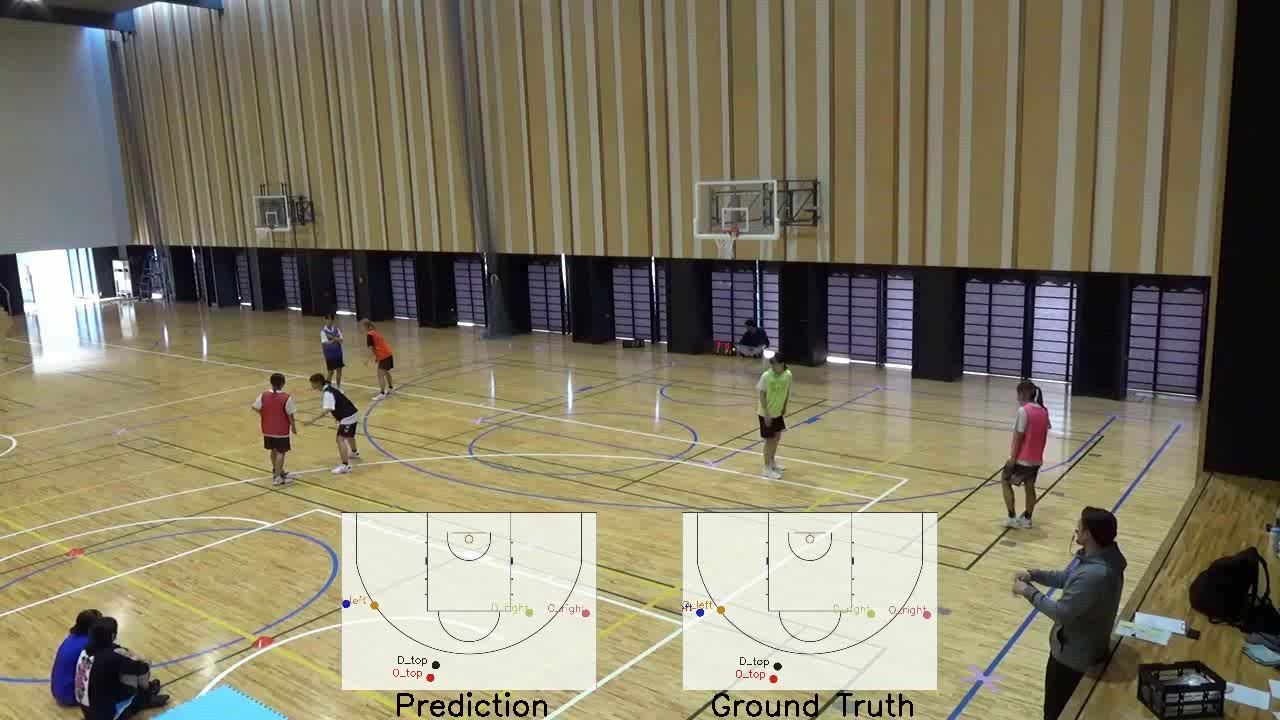

# 13. 選手の移動距離を計算

予測データと正解データを読み込み、各プレイヤーの連続する位置間のユークリッド距離を計算し、これらの距離を合計して総移動距離を算出し、結果を出力します。


In [14]:
df_pred_travel = pd.read_csv(
    output_txt, # output_txt is defined in previous step
    header=None,
    names=['frame', 'ID', 'x', 'y', 'assigned_role'],
    sep=",",
    dtype={'frame': int, 'ID': int, 'x': float, 'y': float, 'assigned_role': str}
)

print("Prediction data loaded successfully. First 5 rows:")
print(df_pred_travel.head())

Prediction data loaded successfully. First 5 rows:
   frame  ID           x           y assigned_role
0      1   2  978.040688  525.764647         O_top
1      2   2  978.022486  525.710194         O_top
2      3   2  978.040409  525.514136         O_top
3      4   2  978.340938  525.450361         O_top
4      5   2  978.509239  525.347689         O_top


In [15]:
df_gt_travel = pd.read_csv(
    gt_file, # gt_file is defined in previous step
    header=None,
    names=['frame', 'ID', 'x', 'y', 'attributes'],
    sep=",",
    dtype={'frame': int, 'ID': int, 'x': float, 'y': float, 'attributes': str}
)

print("Ground Truth data loaded successfully. First 5 rows:")
print(df_gt_travel.head())

Ground Truth data loaded successfully. First 5 rows:
   frame  ID           x            y attributes
0      1   1  985.474386   537.370938      O_top
1      1   2  593.097684   107.065382     O_left
2      1   3  607.812077  1439.290136    O_right
3      1   4  911.005327   561.320969      D_top
4      1   5  578.357248   228.552830     D_left


In [16]:
def calculate_total_travel(df, attribute_col):
    travel_data = []
    for (player_id, attribute_value), group in df.groupby(['ID', attribute_col]):
        # Sort by frame to ensure correct consecutive order
        group = group.sort_values('frame')

        # Calculate differences in x and y coordinates
        dx = np.diff(group['x'].values)
        dy = np.diff(group['y'].values)

        # Combine dx and dy into a 2D array for vectorized norm calculation
        displacements = np.vstack((dx, dy)).T

        # Calculate Euclidean distance for each displacement vector
        distances = np.linalg.norm(displacements, axis=1)

        # Sum the distances to get total travel for the player
        total_player_travel = np.sum(distances)
        travel_data.append({'ID': player_id, 'Attribute': attribute_value, 'Total_Travel': total_player_travel})

    return pd.DataFrame(travel_data)

# Calculate total travel for prediction data
total_travel_pred = calculate_total_travel(df_pred_travel, 'assigned_role')

# Calculate total travel for ground truth data
total_travel_gt = calculate_total_travel(df_gt_travel, 'attributes')

# Add a 'Type' column to distinguish between prediction and ground truth
total_travel_pred['Type'] = 'Prediction'
total_travel_gt['Type'] = 'Ground Truth'

# Concatenate the two DataFrames for comparison
comparison_df = pd.concat([total_travel_pred, total_travel_gt])

# Pivot the table to get 'Prediction' and 'Ground Truth' as columns
pivoted_df = comparison_df.pivot_table(index='Attribute', columns='Type', values='Total_Travel').reset_index()
pivoted_df = pivoted_df.rename_axis(columns=None)

# Reorder columns as requested: Attribute, Prediction, Ground Truth
pivoted_df = pivoted_df[['Attribute', 'Prediction', 'Ground Truth']]

# Format 'Prediction' and 'Ground Truth' columns
pivoted_df['Prediction'] = (pivoted_df['Prediction'] / 100).round(2)
pivoted_df['Ground Truth'] = (pivoted_df['Ground Truth'] / 100).round(2)

# Display the formatted DataFrame with header
print("Comparison of Total Travel Distance [m]:")
print(pivoted_df.to_string(index=False))

Comparison of Total Travel Distance [m]:
Attribute  Prediction  Ground Truth
   D_left       36.92         29.64
  D_right       20.20         18.40
    D_top       29.73         26.87
   O_left       28.08         21.46
  O_right       11.07         10.46
    O_top       24.33         32.66


Saved: /content/runs/detect/track/combined_all_players_paths_minimap_v2.jpg


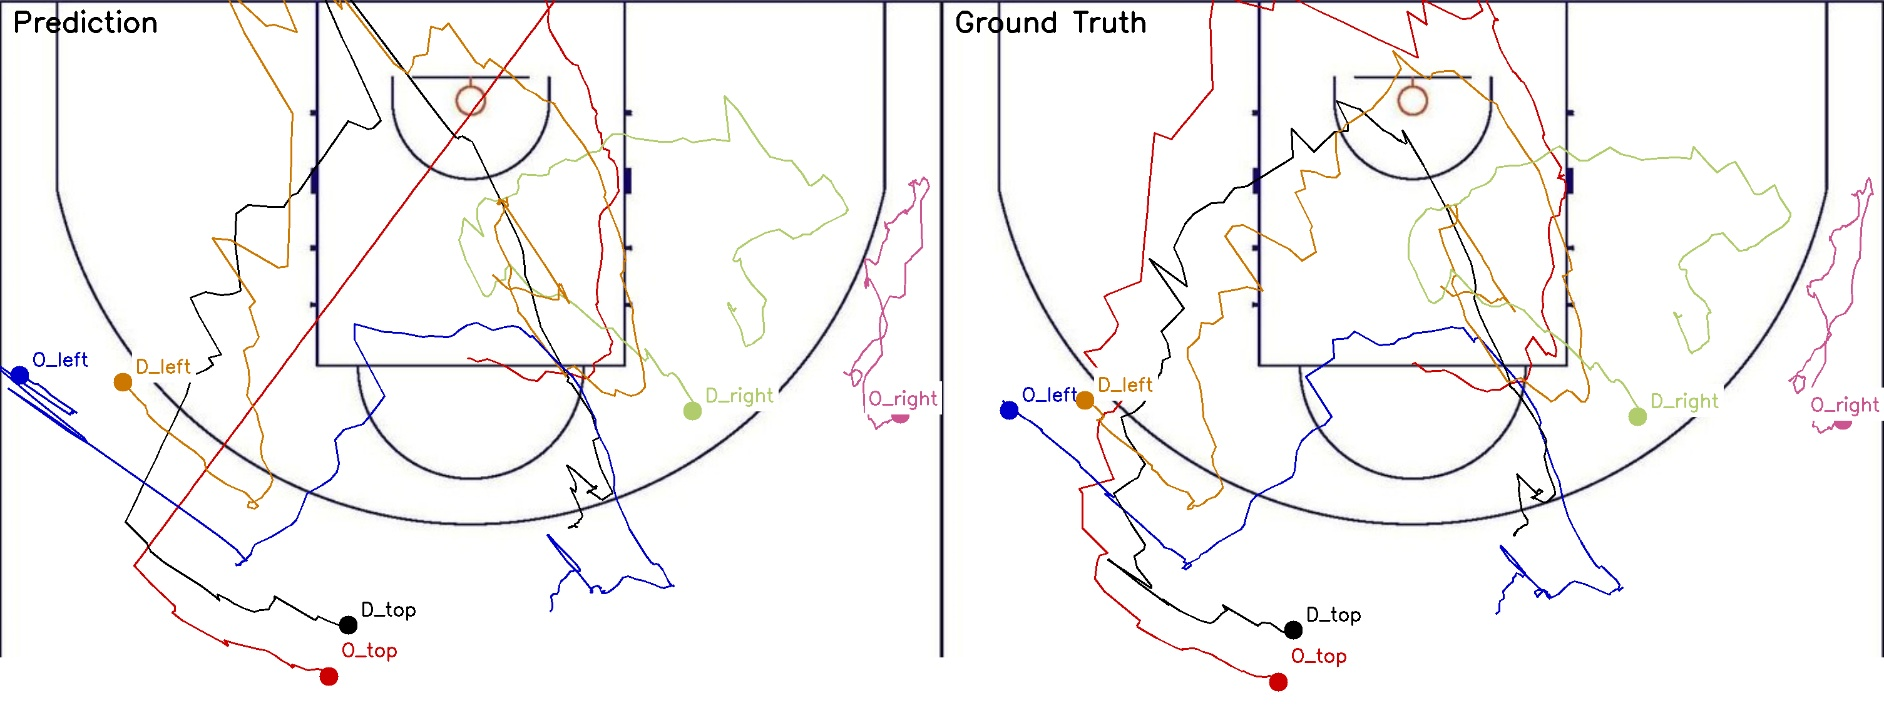

In [17]:
import cv2
import numpy as np
import pandas as pd
import colorsys # For generating distinct colors
import os
from IPython.display import Image, display

# Define standard court dimensions for scaling
COURT_W_CM = 1505  # Court Length (Y in data)
COURT_H_CM = 950   # Court Width (X in data)

# Target Image Dimensions (Landscape)
IMG_W = 1505
IMG_H = 1150 # Increased height to allow for more space below the court drawing
DRAW_H = 1050 # Original image height, now used for scaling the court drawing within the new IMG_H

def scale_coords(x_court, y_court, img_w, draw_h):
    # Swap axes: Court Y -> Image X, Court X -> Image Y
    # This rotates the portrait court coordinates to the landscape image
    img_x = int((y_court / COURT_W_CM) * img_w)
    img_y = int((x_court / COURT_H_CM) * draw_h)
    return img_x, img_y

def draw_text_with_background(img, text, org, font, font_scale, text_color, bg_color, thickness, padding=5):
    (text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale, thickness)
    # Calculate background rectangle coordinates
    x, y = org
    bg_x1 = x - padding
    bg_y1 = y - text_height - baseline - padding
    bg_x2 = x + text_width + padding
    bg_y2 = y + baseline + padding

    # Draw background rectangle
    cv2.rectangle(img, (bg_x1, bg_y1), (bg_x2, bg_y2), bg_color, -1)
    # Draw text
    cv2.putText(img, text, org, font, font_scale, text_color, thickness)
    return img


def draw_all_players_paths_on_minimap(df_travel, base_image_path, title, attribute_colors_map):
    # Load the base court image
    court_img = cv2.imread(base_image_path)
    if court_img is None:
        print(f"Error: Could not load image from {base_image_path}")
        return None

    # Resize the court image to the drawing height, maintaining aspect ratio for width
    # Then create a new canvas with the full IMG_H and paste the resized court image into it.
    court_resized_for_draw_h = cv2.resize(court_img, (IMG_W, DRAW_H))
    minimap_img = np.full((IMG_H, IMG_W, 3), (255, 255, 255), dtype=np.uint8) # Changed to white background
    minimap_img[0:DRAW_H, 0:IMG_W] = court_resized_for_draw_h # Paste court at the top

    # Draw paths for all players
    for player_id in df_travel['ID'].unique():
        player_df = df_travel[df_travel['ID'] == player_id].sort_values('frame')

        if player_df.empty:
            continue

        attribute = player_df['assigned_role'].iloc[0] if 'assigned_role' in player_df.columns else player_df['attributes'].iloc[0]

        # Get color for the player from the consistent attribute map
        color = attribute_colors_map.get(attribute, (255, 255, 255)) # Default white if attribute not in map

        # Convert coordinates for all points in the player's path
        points = []
        for i in range(len(player_df)):
            cx = player_df.iloc[i]['x']
            cy = player_df.iloc[i]['y']
            px, py = scale_coords(cx, cy, IMG_W, DRAW_H)
            points.append((px, py))

        # Draw path lines
        for i in range(1, len(points)):
            cv2.line(minimap_img, points[i-1], points[i], color, 2)

        # Label at the START position
        if not player_df.empty:
            start_x, start_y = scale_coords(player_df.iloc[0]['x'], player_df.iloc[0]['y'], IMG_W, DRAW_H)


            cv2.circle(minimap_img, (start_x, start_y), 15, color, -1) # Increased circle size

            # Adjust text position dynamically to avoid going off-screen
            text_offset_x = 20
            text_offset_y = -15 # Above the circle
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 1.0 # Increased font size
            font_thickness = 2 # Increased thickness
            text_label = f"{attribute}"
            (text_width, text_height), baseline = cv2.getTextSize(text_label, font, font_scale, font_thickness)

            # Horizontal clamping
            text_x = start_x + text_offset_x
            text_x = max(5, min(IMG_W - text_width - 5, text_x))

            # Vertical clamping - prioritize above, but try below if above is cut off
            text_y = start_y + text_offset_y # Initial attempt: above the circle
            if text_y < text_height + 5: # If placing above is cut off at top
                text_y = start_y + 15 + text_height # Try placing below the circle
                if text_y + text_height > DRAW_H - 5: # If placing below also goes off the bottom
                    text_y = DRAW_H - text_height - 5 # Clamp to bottom of drawing area
            elif text_y > DRAW_H - 5: # If placing above is too low (bottom of text box is beyond draw_h)
                text_y = start_y - text_height - 10 # Force above, then re-check top clamp (rare)
                if text_y < text_height + 5:
                    text_y = text_height + 5 # Clamp to top if it's still too high

            draw_text_with_background(minimap_img, text_label, (text_x, text_y), font, font_scale, color, (255,255,255), font_thickness)

    # Add title to the minimap
    cv2.putText(minimap_img, title, (20, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 0), 3) # Changed title color to black and increased size

    return minimap_img

# --- Main part for generating combined shot map ---
# Collect all unique attributes from both datasets
all_attributes = set()
all_attributes.update(df_pred_travel['assigned_role'].unique())
all_attributes.update(df_gt_travel['attributes'].unique())

# Map attributes to specific player IDs (1-6) for consistency with get_color
# Ensure this map covers all attributes present in the data
attribute_string_to_track_id_map = {
    'O_top': 1, 'O_left': 2, 'O_right': 3,
    'D_top': 4, 'D_left': 5, 'D_right': 6
}

attribute_color_map = {}
current_fallback_id = 7 # Start fallback IDs from 7, as get_color has specific rules for 1-6

for attr in sorted(all_attributes):
    if attr in attribute_string_to_track_id_map:
        attribute_color_map[attr] = get_color(attribute_string_to_track_id_map[attr])
    else:
        # For attributes not in the predefined map, generate a new color
        # Using a simple sequential ID for get_color for fallback attributes
        attribute_color_map[attr] = get_color(current_fallback_id)
        current_fallback_id += 1


# Draw prediction minimap
pred_minimap = draw_all_players_paths_on_minimap(
    df_pred_travel, base_image_file, "Prediction", attribute_color_map
)

# Draw ground truth minimap
gt_minimap = draw_all_players_paths_on_minimap(
    df_gt_travel, base_image_file, "Ground Truth", attribute_color_map
)

if pred_minimap is not None and gt_minimap is not None:
    # Resize both minimaps to ensure they have the same height for concatenation
    display_h = 720 # Example display height

    # Calculate target width while maintaining aspect ratio
    pred_h, pred_w, _ = pred_minimap.shape
    gt_h, gt_w, _ = gt_minimap.shape

    # Use the same target height for both
    target_height = display_h
    target_width_pred = int(pred_w * (target_height / pred_h))
    target_width_gt = int(gt_w * (target_height / gt_h))

    pred_minimap_resized = cv2.resize(pred_minimap, (target_width_pred, target_height))
    gt_minimap_resized = cv2.resize(gt_minimap, (target_width_gt, target_height))

    # Concatenate horizontally
    combined_minimap = np.hstack((pred_minimap_resized, gt_minimap_resized))

    # Save the combined minimap
    combined_minimap_filename = os.path.join(out_dir, "combined_all_players_paths_minimap_v2.jpg")
    cv2.imwrite(combined_minimap_filename, combined_minimap)
    print(f"Saved: {combined_minimap_filename}")

    # Display the image in the notebook
    from IPython.display import Image, display
    display(Image(filename=combined_minimap_filename))
else:
    print("Failed to generate one or both minimaps.")